#Global Solution Cognitive Computing, Computer Vision and IoT Systems
Prof. Arnaldo Viana



# Predição de Sucesso em Missões Espaciais Utilizando Machine Learning

## Integrante
Enzo Campos – RM 552006

## Objetivo
Desenvolver um modelo de Machine Learning capaz de prever o sucesso de missões espaciais utilizando dados históricos de lançamentos.

##Fonte Utilizada
https://www.kaggle.com/datasets/agirlcoding/all-space-missions-from-1957/data


##Resultado

A análise exploratória mostrou que a maior parte dos lançamentos espaciais registrados foi realizada por grandes organizações governamentais e empresas do setor aeroespacial.

Tambem foi possível identificar os países com maior numero de lançamentos, destacando Rússia, Eua e Cazaquistão como os principais participantes da atividade espacial historica.

Após o treinamento do modelo Random Forest, a matriz de confusão demonstrou que o modelo identificou corretamente 1.152 missões bem sucedidas, apresentando otimo desempenho para previsão de sucessos.

A base de dados é desbalanceada, contendo aproximadamente 90% de missões bem sucedidas e apenas 10% de falhas, o que impactou a capacidade do modelo em identificar missões fracassadas.




In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
from google.colab import files

uploaded = files.upload()

Saving Space_Corrected.csv to Space_Corrected.csv


In [114]:
import pandas as pd

df = pd.read_csv("Space_Corrected.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Company Name    4324 non-null   object
 3   Location        4324 non-null   object
 4   Datum           4324 non-null   object
 5   Detail          4324 non-null   object
 6   Status Rocket   4324 non-null   object
 7    Rocket         964 non-null    object
 8   Status Mission  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [116]:
df.describe()

,Unnamed: 0.1,Unnamed: 0
count,4324.000000,4324.000000
mean,2161.500000,2161.500000
std,1248.375611,1248.375611
min,0.000000,0.000000
25%,1080.750000,1080.750000
50%,2161.500000,2161.500000
75%,3242.250000,3242.250000
max,4323.000000,4323.000000


In [117]:
df.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
Company Name,0
Location,0
Datum,0
Detail,0
Status Rocket,0
Rocket,3360
Status Mission,0


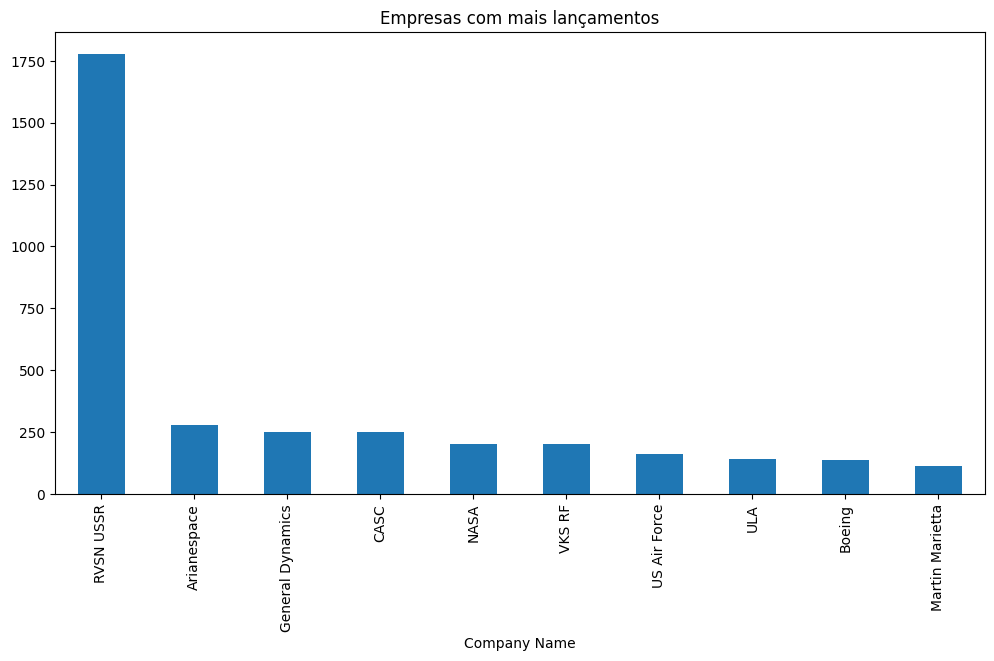

In [118]:
plt.figure(figsize=(12,6))

df['Company Name'].value_counts().head(10).plot(kind='bar')

plt.title('Empresas com mais lançamentos')
plt.show()

In [136]:
df['Country'] = df['Location'].apply(
    lambda x: str(x).split(',')[-1].strip()
)

country_launches = df['Country'].value_counts().head(15)

print(country_launches)

Country
Russia           1395
USA              1344
Kazakhstan        701
France            303
China             268
Japan             126
India              76
Pacific Ocean      36
Iran               13
New Zealand        13
Israel             11
Kenya               9
Australia           6
North Korea         5
New Mexico          4
Name: count, dtype: int64


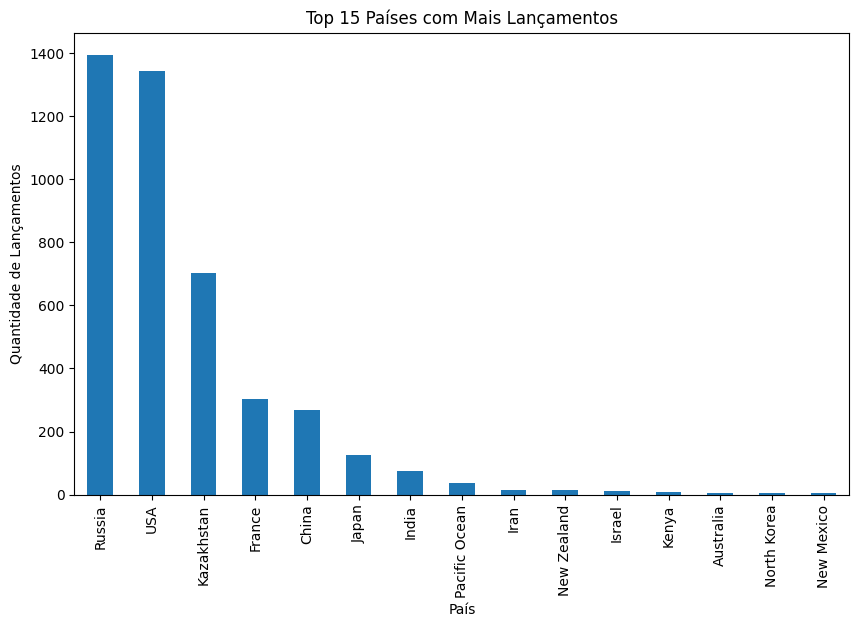

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

country_launches.plot(kind='bar')

plt.title('Top 15 Países com Mais Lançamentos')
plt.xlabel('País')
plt.ylabel('Quantidade de Lançamentos')

plt.show()

In [119]:
df.columns = df.columns.str.strip()
df['Rocket'] = df['Rocket'].fillna(0)

In [120]:
df['Status Mission'].value_counts()

,count
Status Mission,
Success,3879
Failure,339
Partial Failure,102
Prelaunch Failure,4


In [121]:
df['Sucesso'] = df['Status Mission'].apply(
    lambda x: 1 if x == 'Success' else 0
)

In [122]:
for coluna in df:
    print(df[coluna].value_counts())
df['Sucesso'].value_counts()

df.isnull().sum()

Unnamed: 0.1
4323    1
0       1
1       1
2       1
4307    1
       ..
8       1
7       1
6       1
5       1
4       1
Name: count, Length: 4324, dtype: int64
Unnamed: 0
4323    1
0       1
1       1
2       1
4307    1
       ..
8       1
7       1
6       1
5       1
4       1
Name: count, Length: 4324, dtype: int64
Company Name
RVSN USSR           1777
Arianespace          279
General Dynamics     251
CASC                 251
NASA                 203
VKS RF               201
US Air Force         161
ULA                  140
Boeing               136
Martin Marietta      114
SpaceX               100
MHI                   84
Northrop              83
Lockheed              79
ISRO                  76
Roscosmos             55
ILS                   46
Sea Launch            36
ISAS                  30
Kosmotras             22
US Navy               17
Rocket Lab            13
ISA                   13
Eurockot              13
ESA                   13
Blue Origin           12
IAI          

,0
Unnamed: 0.1,0
Unnamed: 0,0
Company Name,0
Location,0
Datum,0
Detail,0
Status Rocket,0
Rocket,0
Status Mission,0
Sucesso,0


In [123]:
from sklearn.preprocessing import LabelEncoder

In [124]:
dados = df[
    [
        'Company Name',
        'Location',
        'Status Rocket'
    ]
].copy()

In [125]:
encoder = LabelEncoder()

for coluna in dados.columns:
    dados[coluna] = encoder.fit_transform(
        dados[coluna].astype(str)
    )

In [126]:
X = dados

df['Sucesso'] = df['Status Mission'].apply(
    lambda x: 1 if x == 'Success' else 0
)

In [127]:
print("Quantidade de registros:", len(df))

print("\nDistribuição das missões:")
print(df['Status Mission'].value_counts())

print("\nDistribuição da variável alvo:")
print(df['Sucesso'].value_counts())

Quantidade de registros: 4324

Distribuição das missões:
Status Mission
Success              3879
Failure               339
Partial Failure       102
Prelaunch Failure       4
Name: count, dtype: int64

Distribuição da variável alvo:
Sucesso
1    3879
0     445
Name: count, dtype: int64


In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [129]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [130]:
previsoes = modelo.predict(X_test)

In [131]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

acc = accuracy_score(
    y_test,
    previsoes
)

print("Acurácia:", acc)

Acurácia: 0.8983050847457628


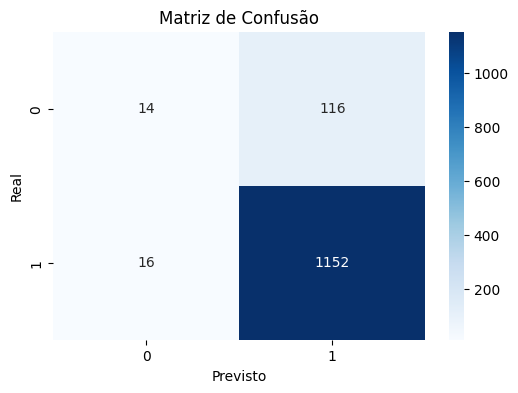

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    previsoes
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusão')

plt.xlabel('Previsto')

plt.ylabel('Real')

plt.show()

In [133]:
print(classification_report(y_test, previsoes))

              precision    recall  f1-score   support

           0       0.47      0.11      0.17       130
           1       0.91      0.99      0.95      1168

    accuracy                           0.90      1298
   macro avg       0.69      0.55      0.56      1298
weighted avg       0.86      0.90      0.87      1298

